# Load package

In [11]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(color_codes=True)

from scipy import stats
from scipy.stats import ttest_rel
import itertools
from scipy.stats import wilcoxon

# Load data

In [ ]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

# Figure 4D -- GCLC-VIM groups

In [3]:
data_tumor = data[data['celltype_1'] == 'Tumor']

In [5]:
df = data_tumor[['RCNs', 'GCLC_VIM']]

# Group the data by RCNs and celltype columns
count_df = df.groupby(['RCNs', 'GCLC_VIM']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['RCNs'].value_counts().sort_index()
# Calculate the percentage of each cell type in each RPD
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
custom_order = ['Tumor.GCLC-VIM-', 'Tumor.GCLC-VIM+', 'Tumor.GCLC+VIM-', 'Tumor.GCLC+VIM+']

# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)
# Sort the RCNs numerically
sorted_rcns = sorted(percent_df.index, key=lambda x: int(x[3:]) if x[3:].isdigit() else float('inf'))
percent_df = percent_df.reindex(sorted_rcns)

## Combined plots

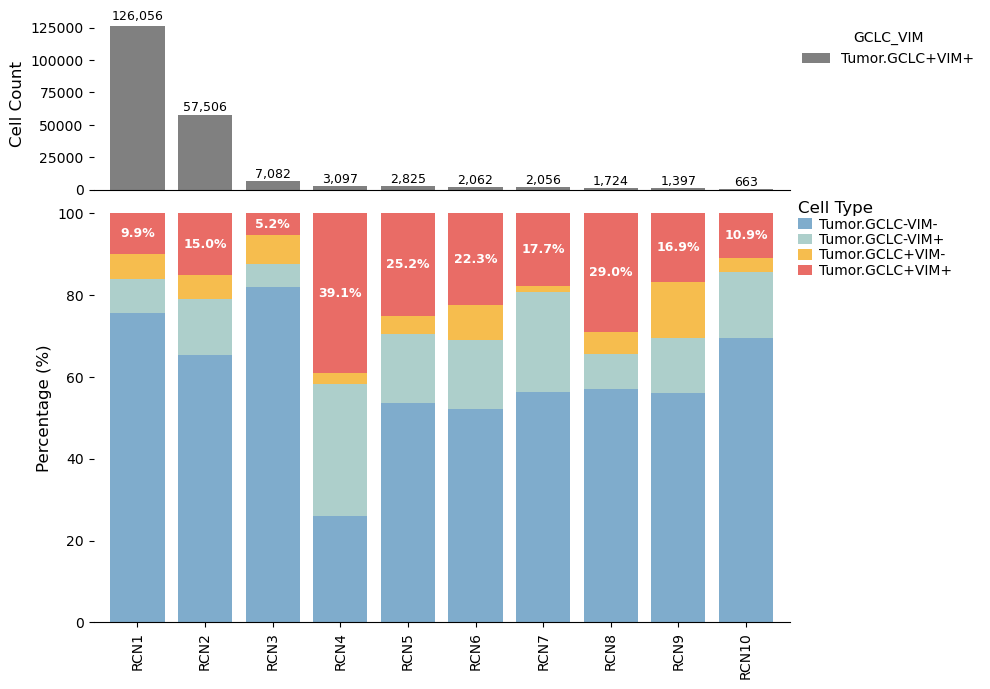

In [12]:
# Sort the count_df for the top plot
count_df_sub = count_df[['Tumor.GCLC+VIM+']]
count_df_sub = count_df_sub.sort_values(by='Tumor.GCLC+VIM+', ascending=False)

# Define colors for each cell type
colors_dict = {
    'Tumor.GCLC-VIM-': '#7FACCC',
    'Tumor.GCLC-VIM+': '#ADCFCB',
    'Tumor.GCLC+VIM-': '#F6BD4E',
    'Tumor.GCLC+VIM+': '#E96C66'
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[0.6, 1.5])

# Top subplot (count plot with gray color)
count_df_sub.plot(kind='bar', color='gray', ax=ax1, width=0.8, edgecolor='none')

# Add count values on top of each bar
for i, value in enumerate(count_df_sub['Tumor.GCLC+VIM+']):
    ax1.text(i, value * 1.02, f'{value:,}', ha='center', va='bottom', fontsize=9)

# Remove spines from top plot
for spine in ax1.spines.values():
    if spine.spine_type != 'bottom':
        spine.set_visible(False)

ax1.set_ylabel('Cell Count', fontsize=12)
ax1.set_title('', fontsize=14)
ax1.set_xlabel('')
# remove x-ticks and labels
ax1.tick_params(axis='x', bottom=False, labelbottom=False)
# add legend for the top plot
ax1.legend(['Tumor.GCLC+VIM+'], title='GCLC_VIM', 
           bbox_to_anchor=(1.0, 1), loc='upper left', 
           fontsize=10, frameon=False)



# Bottom subplot (stacked percentage plot)
percent_df.plot(kind='bar', stacked=True, 
                color=[colors_dict.get(x) for x in percent_df.columns], 
                ax=ax2, width=0.8, edgecolor='none')

# Add percentage values for GCLC+VIM+ (last segment in each stack)
for i, value in enumerate(percent_df['Tumor.GCLC+VIM+']):
    # Calculate the bottom position (sum of other segments)
    bottom = percent_df.iloc[i, 0:3].sum()
    # Add the text in the middle of the segment
    ax2.text(i, bottom + value/2, f'{value:.1f}%', ha='center', va='center', 
             fontsize=9, fontweight='bold', color='white')

# Add the legend to the bottom plot
legend = ax2.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=10,
           frameon=False,
           handleheight=0.8, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
legend.get_title().set_fontsize(12)
legend._legend_box.align = "left"

# Remove spines from bottom plot
for spine in ax2.spines.values():
    if spine.spine_type != 'bottom':
        spine.set_visible(False)

ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_xlabel('', fontsize=12)
ax2.tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.01)

# Show the figure
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/GCLC_VIM_by_RCNs_combined_2.pdf', 
            bbox_inches='tight')
plt.show()

# Figure 2G -- GCLC in VIM-ECAD groups

In [ ]:
VIM_ECA_data = data_tumor[['core_imageid', 'patient_id_AB19_1654', 'GCLC', 'NQO1', 'Vimentin', 'E.Cadherin']]

VIM_ECA_data['VIM_ECA'] = VIM_ECA_data['GCLC']

VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] >= 0.5) & (VIM_ECA_data['E.Cadherin'] >= 0.5), 'VIM_ECA'] = 'VIM+E.Cad+'
VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] < 0.5) & (VIM_ECA_data['E.Cadherin'] >= 0.5), 'VIM_ECA'] = 'VIM-E.Cad+'
VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] >= 0.5) & (VIM_ECA_data['E.Cadherin'] < 0.5), 'VIM_ECA'] = 'VIM+E.Cad-'
VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] < 0.5) & (VIM_ECA_data['E.Cadherin'] < 0.5), 'VIM_ECA'] = 'VIM-E.Cad-'

In [18]:
VIM_ECA_data['VIM_ECA'].value_counts()

VIM_ECA
VIM-E.Cad+    1229458
VIM+E.Cad+     343429
VIM-E.Cad-     163429
VIM+E.Cad-      36844
Name: count, dtype: int64

In [20]:
# Group by patient_id_AB19_1654 and VIM_ECA, and calculate mean GCLC and NQO1
grouped_data = VIM_ECA_data.groupby(['patient_id_AB19_1654', 'VIM_ECA'])[['GCLC', 'NQO1']].mean().reset_index()

# Reshape the data to have patients as rows and VIM_ECA categories as columns
gclc_pivot = grouped_data.pivot(index='patient_id_AB19_1654', columns='VIM_ECA', values='GCLC')
nqo1_pivot = grouped_data.pivot(index='patient_id_AB19_1654', columns='VIM_ECA', values='NQO1')

# Reorder columns in a logical sequence
column_order = ['VIM-E.Cad-', 'VIM-E.Cad+', 'VIM+E.Cad-', 'VIM+E.Cad+']
gclc_pivot = gclc_pivot[column_order]
nqo1_pivot = nqo1_pivot[column_order]

In [ ]:
def plot_violin_with_paired_lines(df, value_col, group_col, id_col,
                                   figsize=(8, 6), palette='white',
                                   save_path=None):
    
    #sns.set(style="whitegrid")
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=figsize)

    # Violin plot
    sns.violinplot(x=group_col, y=value_col, data=df, inner=None, ax=ax, color=palette)

    # Narrower boxplot overlay
    sns.boxplot(x=group_col, y=value_col, data=df, ax=ax,
                width=0.1,
                showcaps=True,
                boxprops={'facecolor':'white', 'zorder':2},
                whiskerprops={'linewidth':1.5},
                showfliers=False)
    
    # Strip plot for individual data points
    sns.stripplot(x=group_col, y=value_col, data=df,
              ax=ax, color='black', size=4, alpha=0.6,
              jitter=False, dodge=True)


    # Pairwise lines
    for sample_id, group in df.groupby(id_col):
        if len(group[group_col].unique()) > 1:
            x = [list(df[group_col].unique()).index(g) for g in group[group_col]]
            y = group[value_col].tolist()
            ax.plot(x, y, color='gray', alpha=0.2, zorder=1)

    # Pairwise t-test with actual p-values and significance stars
    groups = df[group_col].unique()
    pairs = list(itertools.combinations(groups, 2))
    y_max = df[value_col].max()
    for i, (g1, g2) in enumerate(pairs):
        data1 = df[df[group_col] == g1][value_col]
        data2 = df[df[group_col] == g2][value_col]
        common_ids = set(df[df[group_col] == g1][id_col]) & set(df[df[group_col] == g2][id_col])
        if len(common_ids) > 1:
            paired1 = df[(df[group_col] == g1) & (df[id_col].isin(common_ids))].sort_values(id_col)[value_col]
            paired2 = df[(df[group_col] == g2) & (df[id_col].isin(common_ids))].sort_values(id_col)[value_col]
            stat, pval = ttest_rel(paired1.values, paired2.values)
            
            x1, x2 = groups.tolist().index(g1), groups.tolist().index(g2)
            y = y_max + 0.04 + i * 0.05
            h = 0.01
            ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')

            # Add p-value text
            #p_text = f"p = {pval:.1e} {stars}"
            p_text = f"p = {pval:.1e}"
            xpos = (groups.tolist().index(g1) + groups.tolist().index(g2)) / 2
            ax.text(xpos, y_max + 0.05 + i * 0.05, p_text,
                    ha='center', va='bottom', fontsize=10)

    #ax.set_title(value_col)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Figure saved to {save_path}")

    return fig


In [54]:
df_data = grouped_data[grouped_data['VIM_ECA'].isin(['VIM+E.Cad+', 'VIM+E.Cad-', 'VIM-E.Cad+'])]

Figure saved to /Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/GCLC_violin.pdf


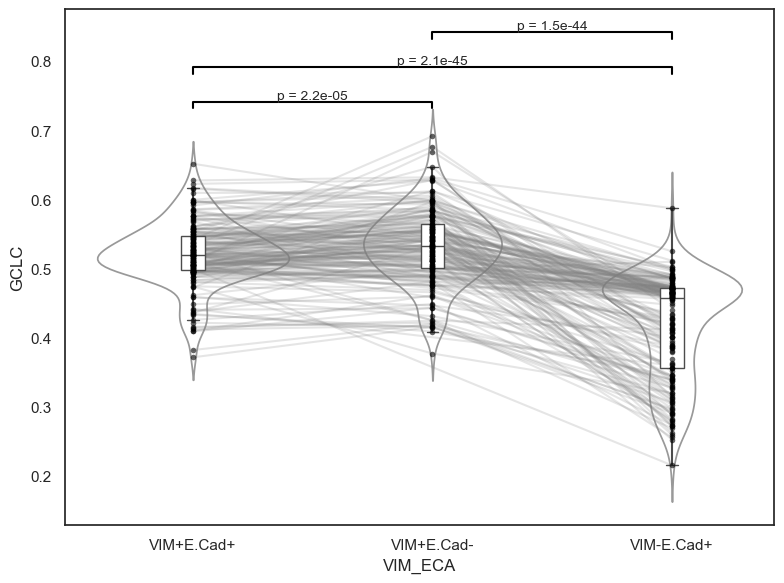

In [59]:
plot_violin_with_paired_lines(df=df_data, value_col='GCLC', group_col='VIM_ECA', id_col='patient_id_AB19_1654',
                              figsize=(8, 6), palette='white',
                              save_path='/Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/GCLC_violin.pdf')
plt.tight_layout()
plt.show()

# Figure 2H -- NQO1 in VIM-ECAD groups

Figure saved to /Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/NQO1_violin.pdf


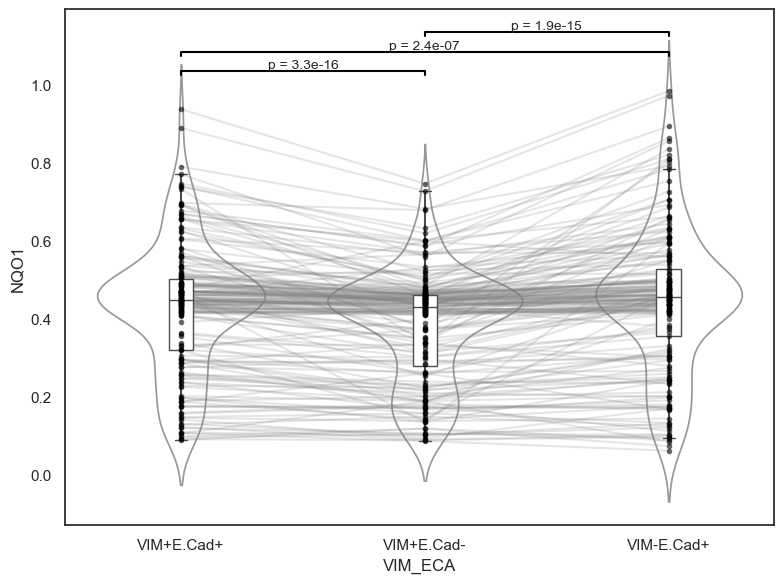

In [60]:
plot_violin_with_paired_lines(df=df_data, value_col='NQO1', group_col='VIM_ECA', id_col='patient_id_AB19_1654',
                              figsize=(8, 6), palette='white',
                              save_path='/Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/NQO1_violin.pdf')
plt.tight_layout()
plt.show()